In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import matplotlib.ticker as ticker

import seaborn as sns

from janitor import clean_names

In [7]:
generation_data = pd.read_csv('data/release_generation_yearly_global.csv')

generation_data = clean_names(generation_data)

generation_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 104099 entries, 0 to 104098
Data columns (total 24 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   area                                      104099 non-null  str    
 1   iso_3_code                                97833 non-null   str    
 2   year                                      104099 non-null  int64  
 3   area_type                                 104099 non-null  str    
 4   electricity_source                        104099 non-null  str    
 5   is_aggregated_source                      104099 non-null  bool   
 6   generation_twh_                           104099 non-null  float64
 7   generation_yoy_change_twh_                100355 non-null  float64
 8   generation_yoy_change_%_                  66920 non-null   float64
 9   share_of_generation_%_                    104065 non-null  float64
 10  share_of_generation_yoy_change_

In [8]:
# calculate Chinese wind and solar total
generation_data = generation_data[generation_data['area_type'] == 'Country or economy']

generation_data = generation_data[generation_data['year'] == generation_data['year'].max()]

chinese_ws = generation_data.loc[(generation_data['electricity_source'] == 'Wind and solar') & (generation_data['area'] == 'China'), 'generation_twh_'].item()

chinese_ws

2310.39

In [9]:
generation_data = generation_data[(generation_data['electricity_source'] == 'Total generation') | ((generation_data['area'] == 'China') & (generation_data['electricity_source'] == 'Wind and solar'))] 

generation_data = generation_data[(generation_data['area'] != 'China') | (generation_data['electricity_source'] != 'Total generation')]

generation_data = generation_data.sort_values(by='generation_twh_', ascending=False, na_position='first').reset_index(drop=True)

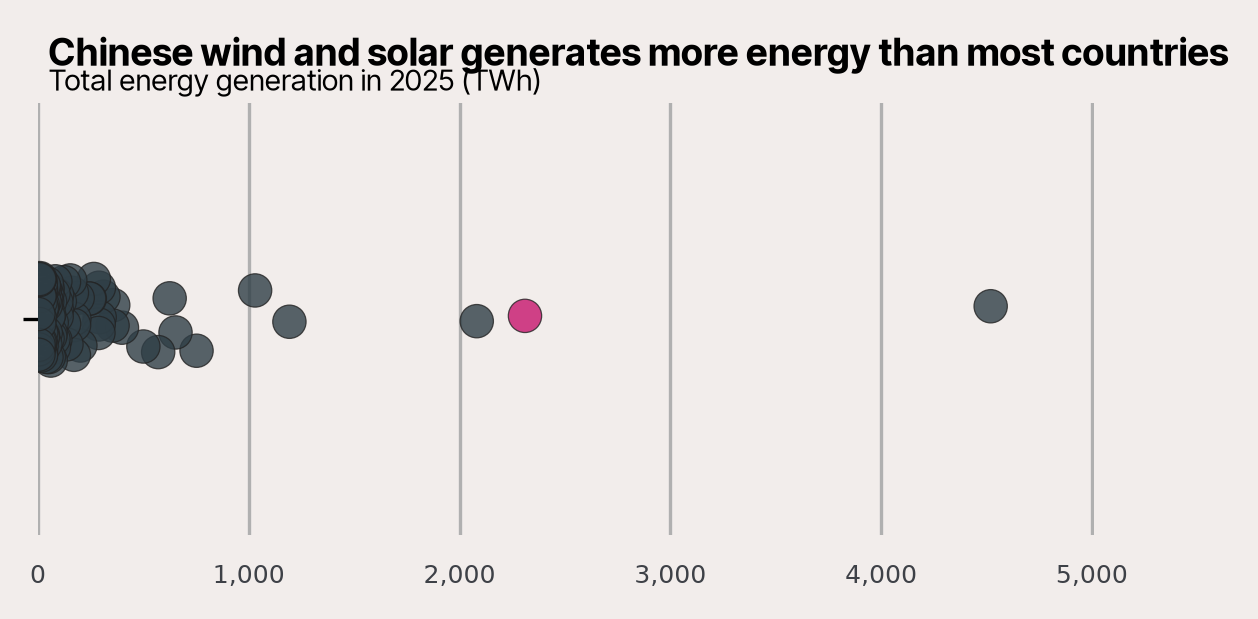

In [ ]:
# ================================
# create beeswarm
# ================================
# set colours
background = '#F2EDEB'
text_colour = "#3E4147"

# set copy
title = "Chinese wind and solar generates more energy than most countries"
subtitle = "Total energy generation in 2025 (TWh)"
x_axis = "Generation (TWh)"

# set typeface properties
title_font = {
    'fontname': 'Inter Tight',
    'weight': 'bold',
    'fontsize': 9
              }

subtitle_font = {
    'fontname': 'Inter Tight',
    'fontsize': 7
              }

# equivalent to R themes() for quick styling
# plt.style.use('seaborn-v0_8')

# call specific elements to update theme
mpl.rcParams['xtick.color'] = text_colour
mpl.rcParams['xtick.labelsize'] = '18'


# set up explicit dimensions
dpi = 300
width_px, height_px = 1920, 1080
figsize = (width_px / dpi, height_px / dpi)


fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
fig.set_facecolor(background)
ax.patch.set_facecolor(background)
# fig.subplots_adjust(left=0.15, right=0.7, bottom=0.45, top=0.85)


ax.text(0.01, 1.065, title, transform=ax.transAxes, ha='left', va='bottom', **title_font)
ax.text(0.01, 1.012, subtitle, transform=ax.transAxes, ha='left', va='bottom', **subtitle_font)


palette = {
    'Total generation': '#2F3E46',
    'Wind and solar': '#C7156D'
}

# ax.set(xscale="log")
sns.stripplot(x='generation_twh_', jitter=True, data=generation_data, size=8, hue='electricity_source', linewidth=0.3,  palette=palette, alpha=0.8)

ax.set_xlim(0, 5010)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', bottom=False, top=False)
plt.grid(axis='x')

ax.tick_params(axis='x', labelsize=6)
ax.set_xlabel(None)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax.get_legend().remove()

for pos in ['right', 'top', 'bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)

plt.savefig("output_300dpi.png", dpi=dpi, facecolor=fig.get_facecolor())

plt.show()

In [39]:
help(ticker.StrMethodFormatter)

Help on class StrMethodFormatter in module matplotlib.ticker:

class StrMethodFormatter(Formatter)
 |  StrMethodFormatter(fmt)
 |
 |  Use a new-style format string (as used by `str.format`) to format the tick.
 |
 |  The field used for the tick value must be labeled *x* and the field used
 |  for the tick position must be labeled *pos*.
 |
 |  The formatter will respect :rc:`axes.unicode_minus` when formatting
 |  negative numeric values.
 |
 |  It is typically unnecessary to explicitly construct `.StrMethodFormatter`
 |  objects, as `~.Axis.set_major_formatter` directly accepts the format string
 |  itself.
 |
 |  Examples
 |  --------
 |  >>> formatter = StrMethodFormatter("{x} km")
 |  >>> formatter(10)
 |  "10 km"
 |
 |  Method resolution order:
 |      StrMethodFormatter
 |      Formatter
 |      TickHelper
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __call__(self, x, pos=None)
 |      Return the formatted label string.
 |
 |      *x* and *pos* are passed to `str.f

In [11]:
# reads available fonts for matplotlib

fm._load_fontmanager(try_read_cache=False)

fonts = sorted(set([f.name for f in mpl.font_manager.fontManager.ttflist]))

for font in fonts:
    print(font)

Arial
Arial Black
Bahnschrift
Calibri
Calibri Light
Cambria
Cambria Math
Candara
Candara Light
Comic Sans MS
Consolas
Constantia
Corbel
Corbel Light
Courier New
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif Display
Ebrima
Franklin Gothic Medium
Gabriola
Gadugi
Georgia
Impact
Ink Free
Inter Tight
Inter Tight Black
Inter Tight ExtraBold
Inter Tight ExtraLight
Inter Tight Light
Inter Tight Medium
Inter Tight SemiBold
Inter Tight Thin
Javanese Text
Last Resort High-Efficiency
Leelawadee UI
Leelawadee UI Semilight
Lucida Console
Lucida Sans Unicode
MS Gothic
MS PGothic
MS UI Gothic
MV Boli
Malgun Gothic
Malgun Gothic Semilight
Microsoft Himalaya
Microsoft JhengHei
Microsoft JhengHei Light
Microsoft JhengHei UI
Microsoft JhengHei UI Light
Microsoft New Tai Lue
Microsoft PhagsPa
Microsoft Sans Serif
Microsoft Tai Le
Microsoft YaHei
Microsoft YaHei Light
Microsoft YaHei UI
Microsoft YaHei UI Light
Microsoft Yi Baiti
MingLiU-ExtB
MingLiU_HKSCS-ExtB
MingLiU_MSCS-ExtB

In [12]:
# clears matplotlib cache when new system font installed

# import shutil
# import matplotlib
# shutil.rmtree(matplotlib.get_cachedir())


In [13]:
# Another way to look at it - how many countries could Chinese wind and solar collectively match